# Notebook 03 – LSTM Experiments (Heavy Variant)

This notebook trains and evaluates the **heavy LSTM configuration**:

| Variant  | Hidden units | Layers | Approx. params |
|----------|-------------|--------|---------------|
| heavy    | 128          | 2      | ~200 k        |

> The medium, light, and tiny variants will be added by other team members.

We measure:
- **Accuracy**: MSE & MAPE on the held-out test set
- **Efficiency**: trainable parameters & model file size
- **Latency**: average inference time per sample

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt

from src.train import train
from src.evaluate import compare_all_variants

%matplotlib inline

CSV_PATH    = '../data/raw/train.csv'
MODELS_DIR  = '../models'
RESULTS_DIR = '../results'
EPOCHS      = 20
BATCH_SIZE  = 256

## 1. Train Heavy LSTM

> **Note:** Training the heavy variant on CPU takes ~15–30 min. Use a GPU runtime or reduce `EPOCHS` for quick experimentation.

In [2]:
print(f'{"="*60}')
print(f'  Training variant: HEAVY')
print(f'{"="*60}')

model, history = train(
    csv_path=CSV_PATH,
    variant='heavy',
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    models_dir=MODELS_DIR,
    results_dir=RESULTS_DIR,
)

  Training variant: HEAVY
Device: cpu
Loading and preprocessing data …
  Data loaded in 0.7s
  Train samples : 727,000
  Val   samples : 81,000
  Test  samples : 90,000
  Window size   : 30
  Train batches : 2,840  (batch_size=256)
  Val   batches : 317
Variant 'heavy' | Parameters: 199,297

  Starting training: 20 epochs, lr=0.001
  Epoch   1/20  train_mse=0.002541  val_mse=0.001877  (176.7s) ↓ best
  Epoch   2/20  train_mse=0.001527  val_mse=0.001725  (175.5s) ↓ best
  Epoch   3/20  train_mse=0.001443  val_mse=0.001663  (178.7s) ↓ best
  Epoch   4/20  train_mse=0.001415  val_mse=0.001702  (181.9s) 
  Epoch   5/20  train_mse=0.001403  val_mse=0.001581  (175.7s) ↓ best
  Epoch   6/20  train_mse=0.001395  val_mse=0.001596  (196.7s) 
  Epoch   7/20  train_mse=0.001384  val_mse=0.001645  (205.4s) 
  Epoch   8/20  train_mse=0.001379  val_mse=0.001576  (538.8s) ↓ best
  Epoch   9/20  train_mse=0.001374  val_mse=0.001645  (195.3s) 
  Epoch  10/20  train_mse=0.001373  val_mse=0.001557  (193.2

## 2. Training Loss Curves

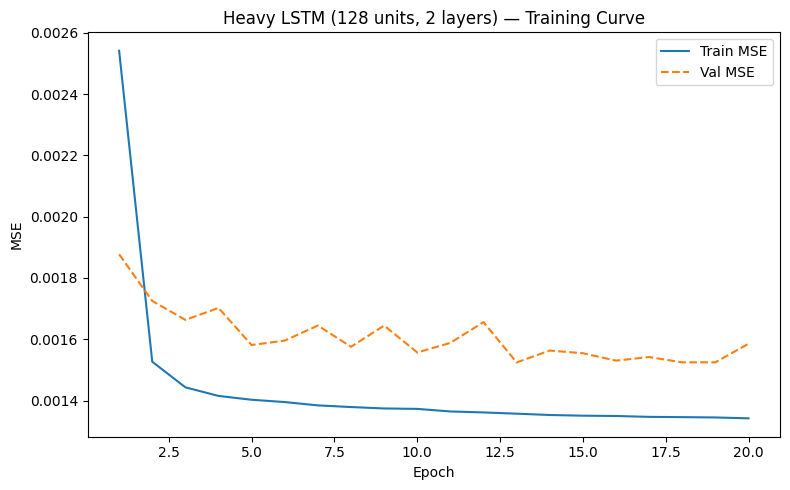

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(history['epoch'], history['train_mse'], label='Train MSE')
ax.plot(history['epoch'], history['val_mse'],   label='Val MSE', linestyle='--')
ax.set_title('Heavy LSTM (128 units, 2 layers) — Training Curve')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.legend()

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/lstm_loss_curves.png', dpi=120)
plt.show()

## 3. Evaluate Heavy Variant

In [4]:
summary = compare_all_variants(
    variants=('heavy',),
    csv_path=CSV_PATH,
    models_dir=MODELS_DIR,
    results_dir=RESULTS_DIR,
)
summary

KeyboardInterrupt: 

## 4. Accuracy vs Efficiency Trade-off

> These plots will become more informative once teammates add the medium, light, and tiny variants. For now they show the heavy data point as a reference.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# MAPE vs Parameters
axes[0].scatter(summary['n_parameters'], summary['mape_pct'], s=80, color='steelblue')
for _, row in summary.iterrows():
    axes[0].annotate(row['variant'], (row['n_parameters'], row['mape_pct']),
                     textcoords='offset points', xytext=(5, 5))
axes[0].set_xlabel('Trainable Parameters')
axes[0].set_ylabel('MAPE (%)')
axes[0].set_title('Accuracy vs Parameters')

# MAPE vs File Size
axes[1].scatter(summary['file_size_kb'], summary['mape_pct'], s=80, color='darkorange')
for _, row in summary.iterrows():
    axes[1].annotate(row['variant'], (row['file_size_kb'], row['mape_pct']),
                     textcoords='offset points', xytext=(5, 5))
axes[1].set_xlabel('Model File Size (KB)')
axes[1].set_ylabel('MAPE (%)')
axes[1].set_title('Accuracy vs File Size')

# MAPE vs Latency
axes[2].scatter(summary['latency_ms'], summary['mape_pct'], s=80, color='seagreen')
for _, row in summary.iterrows():
    axes[2].annotate(row['variant'], (row['latency_ms'], row['mape_pct']),
                     textcoords='offset points', xytext=(5, 5))
axes[2].set_xlabel('Inference Latency (ms)')
axes[2].set_ylabel('MAPE (%)')
axes[2].set_title('Accuracy vs Latency')

plt.suptitle('Accuracy–Efficiency Trade-off', fontsize=14)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/accuracy_efficiency_tradeoff.png', dpi=120)
plt.show()

## 5. Summary Table

In [ ]:
display(summary.sort_values('mape_pct'))